In [2]:

!pip install -q tensorflow pandas numpy scipy scikit-learn

In [3]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import os
import json
import pickle
import re

import numpy as np
import pandas as pd
import tensorflow as tf

from collections import OrderedDict

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [4]:
# ============================================================
# CELL 5: LOAD CANONICAL LIGANDS
# ============================================================

with open(
    "ligands_can.txt",
    "r"
) as f:

    ligands_can_dict = json.load(
        f,
        object_pairs_hook=OrderedDict
    )


ligands_can = pd.DataFrame(
    list(ligands_can_dict.items()),
    columns=[
        "drug_id",
        "smiles_can"
    ]
)


print(
    "Number of canonical ligands:",
    len(ligands_can)
)

display(
    ligands_can.head(10)
)

Number of canonical ligands: 68


,drug_id,smiles_can
0,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...
1,24889392,CC(C)(C)C1=CC(=NO1)NC(=O)NC2=CC=C(C=C2)C3=CN4C...
2,11409972,CCN1CCN(CC1)CC2=C(C=C(C=C2)NC(=O)NC3=CC=C(C=C3...
3,11338033,C1CNCCC1NC(=O)C2=C(C=NN2)NC(=O)C3=C(C=CC=C3Cl)Cl
4,10184653,CN(C)CC=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(...
5,5287969,CN1CCC(C(C1)O)C2=C(C=C(C3=C2OC(=CC3=O)C4=CC=CC...
6,6450551,CNC(=O)C1=CC=CC=C1SC2=CC3=C(C=C2)C(=NN3)C=CC4=...
7,11364421,CCC1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=C(C=C...
8,9926054,CC1=CC2=C(C=C1)N=C(C3=NC=C(N23)C)NCCN.Cl
9,16007391,CCN(CCCOC1=CC2=C(C=C1)C(=NC=N2)NC3=NNC(=C3)CC(...


In [5]:
# ============================================================
# CELL 6: LOAD ISOMERIC LIGANDS
# ============================================================

with open(
    "ligands_iso.txt",
    "r"
) as f:

    ligands_iso_dict = json.load(
        f,
        object_pairs_hook=OrderedDict
    )


ligands_iso = pd.DataFrame(
    list(ligands_iso_dict.items()),
    columns=[
        "drug_id",
        "smiles_iso"
    ]
)


print(
    "Number of isomeric ligands:",
    len(ligands_iso)
)

display(
    ligands_iso.head(10)
)

Number of isomeric ligands: 68


,drug_id,smiles_iso
0,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
1,24889392,CC(C)(C)C1=CC(=NO1)NC(=O)NC2=CC=C(C=C2)C3=CN4C...
2,11409972,CCN1CCN(CC1)CC2=C(C=C(C=C2)NC(=O)NC3=CC=C(C=C3...
3,11338033,C1CNCCC1NC(=O)C2=C(C=NN2)NC(=O)C3=C(C=CC=C3Cl)Cl
4,10184653,CN(C)C/C=C/C(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=C...
5,5287969,CN1CC[C@@H]([C@@H](C1)O)C2=C(C=C(C3=C2OC(=CC3=...
6,6450551,CNC(=O)C1=CC=CC=C1SC2=CC3=C(C=C2)C(=NN3)/C=C/C...
7,11364421,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...
8,9926054,CC1=CC2=C(C=C1)N=C(C3=NC=C(N23)C)NCCN.Cl
9,16007391,CCN(CCCOC1=CC2=C(C=C1)C(=NC=N2)NC3=NNC(=C3)CC(...


In [6]:
# ============================================================
# CELL 7: COMPARE CANONICAL AND ISOMERIC SMILES
# ============================================================

ligands = ligands_can.merge(
    ligands_iso,
    on="drug_id",
    how="outer"
)


print(
    "Total ligand records:",
    len(ligands)
)


print(
    "Missing canonical SMILES:",
    ligands["smiles_can"].isna().sum()
)


print(
    "Missing isomeric SMILES:",
    ligands["smiles_iso"].isna().sum()
)


print("\nFirst few ligands:")

display(
    ligands.head(10)
)

Total ligand records: 68
Missing canonical SMILES: 0
Missing isomeric SMILES: 0

First few ligands:


,drug_id,smiles_can,smiles_iso
0,10074640,CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C...,CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C...
1,10113978,CC1=C(C=C(C=C1)NC2=NC=CC(=N2)N(C)C3=CC4=NN(C(=...,CC1=C(C=C(C=C1)NC2=NC=CC(=N2)N(C)C3=CC4=NN(C(=...
2,10127622,CN1C=NC2=C1C=C(C(=C2F)NC3=C(C=C(C=C3)Br)Cl)C(=...,CN1C=NC2=C1C=C(C(=C2F)NC3=C(C=C(C=C3)Br)Cl)C(=...
3,10138260,CC1=C(NC(=C1C(=O)NCC(CN2CCOCC2)O)C)C=C3C4=C(C=...,CC1=C(NC(=C1C(=O)NCC(CN2CCOCC2)O)C)/C=C\3/C4=C...
4,10184653,CN(C)CC=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(...,CN(C)C/C=C/C(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=C...
5,10427712,C1=CC(=CC(=C1)O)C2=NC3=C(N=C2C4=CC(=CC=C4)O)N=...,C1=CC(=CC(=C1)O)C2=NC3=C(N=C2C4=CC(=CC=C4)O)N=...
6,10461815,CC1=C(NC(=C1C(=O)N2CCCC2CN3CCCC3)C)C=C4C5=C(C=...,CC1=C(NC(=C1C(=O)N2CCC[C@@H]2CN3CCCC3)C)/C=C\4...
7,11234052,CC1=CC2=C(N1)C=CC(=C2F)OC3=NC=NN4C3=C(C(=C4)OC...,CC1=CC2=C(N1)C=CC(=C2F)OC3=NC=NN4C3=C(C(=C4)OC...
8,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
9,11338033,C1CNCCC1NC(=O)C2=C(C=NN2)NC(=O)C3=C(C=CC=C3Cl)Cl,C1CNCCC1NC(=O)C2=C(C=NN2)NC(=O)C3=C(C=CC=C3Cl)Cl


In [7]:
# ============================================================
# CELL 8: CHECK LIGAND IDs
# ============================================================

can_ids = set(
    ligands_can["drug_id"]
)

iso_ids = set(
    ligands_iso["drug_id"]
)


print(
    "IDs only in canonical file:",
    len(can_ids - iso_ids)
)

print(
    "IDs only in isomeric file:",
    len(iso_ids - can_ids)
)

print(
    "Common ligand IDs:",
    len(can_ids & iso_ids)
)

IDs only in canonical file: 0
IDs only in isomeric file: 0
Common ligand IDs: 68


In [8]:
# ============================================================
# CELL 9: LOAD PROTEINS
# ============================================================

with open(
    "proteins.txt",
    "r"
) as f:

    proteins_dict = json.load(
        f,
        object_pairs_hook=OrderedDict
    )


proteins = pd.DataFrame(
    list(proteins_dict.items()),
    columns=[
        "target_id",
        "sequence"
    ]
)


print(
    "Number of proteins:",
    len(proteins)
)

display(
    proteins.head(10)
)

Number of proteins: 442


,target_id,sequence
0,AAK1,MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQV...
1,ABL1(E255K),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
2,ABL1(F317I),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
3,ABL1(F317I)p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
4,ABL1(F317L),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
5,ABL1(F317L)p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
6,ABL1(H396P),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
7,ABL1(H396P)p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
8,ABL1(M351T),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
9,ABL1(Q252H),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...


In [9]:
# ============================================================
# CELL 10: LOAD RAW DAVIS Kd AFFINITY FILE
# ============================================================

raw_affinity_file = (
    "drug-target_interaction_affinities_Kd__Davis_et_al.2011v1.txt"
)

print("First 10 lines of raw affinity file:\n")

with open(
    raw_affinity_file,
    "r"
) as f:

    for i in range(10):

        line = f.readline()

        if not line:
            break

        print(line.rstrip())

First 10 lines of raw affinity file:

43 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 76 2900 180 10000 10000 10000 10000 10000 10000 10000 10000 10000 8400 10000 120 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 2400 10000 320 970 270 890 710 810 740 10000 10000 10000 3100 1300 10000 2700 10000 10000 10000 70 3500 180 10000 700 1100 200 10000 9800 13 1.4 0.51 160 0.53 10000 10000 2100 4600 210 120 530 380 910 5500 3800 10000 1600 2500 1200 10000 10000 10000 10000 10000 10000 92 460 5200 5200 2.1 3.9 63 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 89 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 10000 540 78 43 83 500 200 1800 10000 10000 10000 180 10000 10000 1400 1900 3900 350 10000 230 220 110 76

In [10]:
# ============================================================
# CELL 11: LOAD RAW Kd MATRIX
# ============================================================

raw_Kd = pd.read_csv(
    raw_affinity_file,
    sep="\t",
    header=None
)


print(
    "Raw Kd matrix shape:",
    raw_Kd.shape
)


display(
    raw_Kd.iloc[:5, :5]
)

Raw Kd matrix shape: (68, 1)


,0
0,43 10000 10000 10000 10000 10000 10000 10000 1...
1,10000 10000 10000 10000 10000 10000 10000 1000...
2,10000 75 1.9 13 0.77 13 2.6 31 34 0.93 31 2.8 ...
3,10000 10000 10000 10000 10000 10000 10000 1000...
4,10000 420 2900 750 580 230 500 500 1200 790 38...


In [11]:
# ============================================================
# CELL 12: LOAD Y
# ============================================================

with open(
    "Y",
    "rb"
) as f:

    Y = pickle.load(
        f,
        encoding="latin1"
    )


Y = np.asarray(Y)


print(
    "Y shape:",
    Y.shape
)

print(
    "Y dtype:",
    Y.dtype
)

print(
    "\nFirst 5 x 5 values:"
)

print(
    Y[:5, :5]
)

Y shape: (68, 442)
Y dtype: float64

First 5 x 5 values:
[[4.3e+01 1.0e+04 1.0e+04 1.0e+04 1.0e+04]
 [1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04]
 [1.0e+04 7.5e+01 1.9e+00 1.3e+01 7.7e-01]
 [1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04]
 [1.0e+04 4.2e+02 2.9e+03 7.5e+02 5.8e+02]]


In [12]:
# ============================================================
# CELL 13: COMPARE AFFINITY MATRICES
# ============================================================

print(
    "Raw Kd shape:",
    raw_Kd.shape
)

print(
    "Y shape:",
    Y.shape
)

print(
    "Number of drugs:",
    len(ligands_can)
)

print(
    "Number of proteins:",
    len(proteins)
)

Raw Kd shape: (68, 1)
Y shape: (68, 442)
Number of drugs: 68
Number of proteins: 442


In [13]:
# ============================================================
# CELL 14: CONVERT Kd → pKd
# ============================================================

Y_pKd = np.full_like(
    Y,
    np.nan,
    dtype=np.float32
)


valid_mask = ~np.isnan(Y)


Y_pKd[valid_mask] = (
    -np.log10(
        Y[valid_mask] / 1e9
    )
)


print(
    "Original Kd minimum:",
    np.nanmin(Y)
)

print(
    "Original Kd maximum:",
    np.nanmax(Y)
)


print(
    "\npKd minimum:",
    np.nanmin(Y_pKd)
)

print(
    "pKd maximum:",
    np.nanmax(Y_pKd)
)

Original Kd minimum: 0.016
Original Kd maximum: 10000.0

pKd minimum: 5.0
pKd maximum: 10.79588


In [14]:
# ============================================================
# CELL 15: COUNT VALID INTERACTIONS
# ============================================================

total_entries = Y.size

missing_entries = np.isnan(Y).sum()

valid_entries = (
    ~np.isnan(Y)
).sum()


print(
    "Total possible drug-target pairs:",
    total_entries
)

print(
    "Missing pairs:",
    missing_entries
)

print(
    "Valid experimental interactions:",
    valid_entries
)

print(
    "Percentage valid:",
    valid_entries /
    total_entries * 100
)

Total possible drug-target pairs: 30056
Missing pairs: 0
Valid experimental interactions: 30056
Percentage valid: 100.0


In [15]:
# ============================================================
# CELL 16: CREATE INDEX MAPPINGS
# ============================================================

drug_ids = list(
    ligands_can_dict.keys()
)

target_ids = list(
    proteins_dict.keys()
)


drug_to_index = {
    drug_id: i
    for i, drug_id
    in enumerate(drug_ids)
}


target_to_index = {
    target_id: i
    for i, target_id
    in enumerate(target_ids)
}


print(
    "Drug IDs:",
    len(drug_ids)
)

print(
    "Target IDs:",
    len(target_ids)
)

Drug IDs: 68
Target IDs: 442


In [16]:
# ============================================================
# CELL 17: FLATTEN VALID DRUG-TARGET INTERACTIONS
# ============================================================

label_row_inds, label_col_inds = np.where(
    ~np.isnan(Y)
)


print(
    "Number of flattened interactions:",
    len(label_row_inds)
)


pairs = []


for k in range(
    len(label_row_inds)
):

    drug_index = label_row_inds[k]

    target_index = label_col_inds[k]

    pairs.append({

        "drug_index":
            drug_index,

        "target_index":
            target_index,

        "drug_id":
            drug_ids[drug_index],

        "target_id":
            target_ids[target_index],

        "Kd":
            Y[
                drug_index,
                target_index
            ],

        "pKd":
            Y_pKd[
                drug_index,
                target_index
            ]
    })


affinity_pairs = pd.DataFrame(
    pairs
)


print(
    "Affinity pairs shape:",
    affinity_pairs.shape
)


display(
    affinity_pairs.head(10)
)

Number of flattened interactions: 30056
Affinity pairs shape: (30056, 6)


,drug_index,target_index,drug_id,target_id,Kd,pKd
0,0,0,11314340,AAK1,43.0,7.366531
1,0,1,11314340,ABL1(E255K),10000.0,5.000000
2,0,2,11314340,ABL1(F317I),10000.0,5.000000
3,0,3,11314340,ABL1(F317I)p,10000.0,5.000000
4,0,4,11314340,ABL1(F317L),10000.0,5.000000
5,0,5,11314340,ABL1(F317L)p,10000.0,5.000000
6,0,6,11314340,ABL1(H396P),10000.0,5.000000
7,0,7,11314340,ABL1(H396P)p,10000.0,5.000000
8,0,8,11314340,ABL1(M351T),10000.0,5.000000
9,0,9,11314340,ABL1(Q252H),10000.0,5.000000


In [17]:
# ============================================================
# CELL 17: FLATTEN VALID DRUG-TARGET INTERACTIONS
# ============================================================

label_row_inds, label_col_inds = np.where(
    ~np.isnan(Y)
)


print(
    "Number of flattened interactions:",
    len(label_row_inds)
)


pairs = []


for k in range(
    len(label_row_inds)
):

    drug_index = label_row_inds[k]

    target_index = label_col_inds[k]

    pairs.append({

        "drug_index":
            drug_index,

        "target_index":
            target_index,

        "drug_id":
            drug_ids[drug_index],

        "target_id":
            target_ids[target_index],

        "Kd":
            Y[
                drug_index,
                target_index
            ],

        "pKd":
            Y_pKd[
                drug_index,
                target_index
            ]
    })


affinity_pairs = pd.DataFrame(
    pairs
)


print(
    "Affinity pairs shape:",
    affinity_pairs.shape
)


display(
    affinity_pairs.head(10)
)

Number of flattened interactions: 30056
Affinity pairs shape: (30056, 6)


,drug_index,target_index,drug_id,target_id,Kd,pKd
0,0,0,11314340,AAK1,43.0,7.366531
1,0,1,11314340,ABL1(E255K),10000.0,5.000000
2,0,2,11314340,ABL1(F317I),10000.0,5.000000
3,0,3,11314340,ABL1(F317I)p,10000.0,5.000000
4,0,4,11314340,ABL1(F317L),10000.0,5.000000
5,0,5,11314340,ABL1(F317L)p,10000.0,5.000000
6,0,6,11314340,ABL1(H396P),10000.0,5.000000
7,0,7,11314340,ABL1(H396P)p,10000.0,5.000000
8,0,8,11314340,ABL1(M351T),10000.0,5.000000
9,0,9,11314340,ABL1(Q252H),10000.0,5.000000


In [18]:
# ============================================================
# CELL 18: MERGE BOTH LIGAND REPRESENTATIONS
# ============================================================

data = affinity_pairs.merge(
    ligands,
    on="drug_id",
    how="left"
)


data = data.merge(
    proteins,
    on="target_id",
    how="left"
)


print(
    "Final dataset shape:",
    data.shape
)


display(
    data.head()
)

Final dataset shape: (30056, 9)


,drug_index,target_index,drug_id,target_id,Kd,pKd,smiles_can,smiles_iso,sequence
0,0,0,11314340,AAK1,43.0,7.366531,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQV...
1,0,1,11314340,ABL1(E255K),10000.0,5.000000,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
2,0,2,11314340,ABL1(F317I),10000.0,5.000000,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
3,0,3,11314340,ABL1(F317I)p,10000.0,5.000000,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
4,0,4,11314340,ABL1(F317L),10000.0,5.000000,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...


In [19]:
# ============================================================
# CELL 19: DATA QUALITY CHECK
# ============================================================

print("Missing values:\n")

print(
    data[
        [
            "drug_id",
            "target_id",
            "Kd",
            "pKd",
            "smiles_can",
            "smiles_iso",
            "sequence"
        ]
    ].isna().sum()
)


print(
    "\nDuplicate interaction rows:",
    data.duplicated(
        subset=[
            "drug_id",
            "target_id"
        ]
    ).sum()
)


print(
    "\nUnique drugs:",
    data["drug_id"].nunique()
)


print(
    "Unique proteins:",
    data["target_id"].nunique()
)


print(
    "Interactions:",
    len(data)
)

Missing values:

drug_id       0
target_id     0
Kd            0
pKd           0
smiles_can    0
smiles_iso    0
sequence      0
dtype: int64

Duplicate interaction rows: 0

Unique drugs: 68
Unique proteins: 442
Interactions: 30056


In [20]:
# ============================================================
# CELL 20: SMILES COMPARISON
# ============================================================

different_smiles = (
    data["smiles_can"]
    !=
    data["smiles_iso"]
)


print(
    "Interactions with different "
    "canonical/isomeric SMILES:",
    different_smiles.sum()
)


display(
    data.loc[
        different_smiles,
        [
            "drug_id",
            "smiles_can",
            "smiles_iso"
        ]
    ].head(10)
)

Interactions with different canonical/isomeric SMILES: 10166


,drug_id,smiles_can,smiles_iso
0,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
1,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
2,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
3,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
4,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
5,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
6,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
7,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
8,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
9,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...


In [21]:
# ============================================================
# CELL 21: SELECT LIGAND REPRESENTATION
# ============================================================

data["smiles"] = data[
    "smiles_can"
]


print(
    "Ligand representation used by CNN:"
)

print(
    "Canonical SMILES"
)


display(
    data[
        [
            "drug_id",
            "smiles",
            "smiles_iso"
        ]
    ].head()
)

Ligand representation used by CNN:
Canonical SMILES


,drug_id,smiles,smiles_iso
0,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
1,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
2,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
3,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...
4,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...


In [22]:
# ============================================================
# CELL 22: SMILES TOKENIZER
# ============================================================

def tokenize_smiles(smiles):

    pattern = (
        r'\[[^\]]+\]'
        r'|Br|Cl|Si|Se|Na|Ca|Li|Mg|Al|Fe|Zn|Cu'
        r'|[A-Za-z]'
        r'|\d'
        r'|[().=#\-+/\\:@?*]'
    )

    return re.findall(
        pattern,
        str(smiles)
    )

In [23]:
# ============================================================
# CELL 23: TEST SMILES TOKENIZATION
# ============================================================

for i in range(5):

    smiles = data[
        "smiles"
    ].iloc[i]

    print(
        "\nSMILES:",
        smiles
    )

    print(
        "Tokens:",
        tokenize_smiles(smiles)
    )


SMILES: CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N
Tokens: ['C', 'C', '1', '=', 'C', '2', 'C', '=', 'C', '(', 'C', '=', 'C', 'C', '2', '=', 'N', 'N', '1', ')', 'C', '3', '=', 'C', 'C', '(', '=', 'C', 'N', '=', 'C', '3', ')', 'O', 'C', 'C', '(', 'C', 'C', '4', '=', 'C', 'C', '=', 'C', 'C', '=', 'C', '4', ')', 'N']

SMILES: CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N
Tokens: ['C', 'C', '1', '=', 'C', '2', 'C', '=', 'C', '(', 'C', '=', 'C', 'C', '2', '=', 'N', 'N', '1', ')', 'C', '3', '=', 'C', 'C', '(', '=', 'C', 'N', '=', 'C', '3', ')', 'O', 'C', 'C', '(', 'C', 'C', '4', '=', 'C', 'C', '=', 'C', 'C', '=', 'C', '4', ')', 'N']

SMILES: CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N
Tokens: ['C', 'C', '1', '=', 'C', '2', 'C', '=', 'C', '(', 'C', '=', 'C', 'C', '2', '=', 'N', 'N', '1', ')', 'C', '3', '=', 'C', 'C', '(', '=', 'C', 'N', '=', 'C', '3', ')', 'O', 'C', 'C', '(', 'C', 'C', '4', '=', 'C', 'C', '=', 'C', 'C', '=', 'C', '4', ')', 'N']

SMILES: CC1=C2C=C(C=CC2=

In [24]:
# ============================================================
# CELL 24: BUILD SMILES VOCABULARY
# ============================================================

all_smiles_tokens = set()


for smiles in data["smiles"]:

    tokens = tokenize_smiles(
        smiles
    )

    all_smiles_tokens.update(
        tokens
    )


smiles_tokens = sorted(
    all_smiles_tokens
)


smiles_vocab = {
    token: index + 1
    for index, token
    in enumerate(smiles_tokens)
}


# Padding = 0
smiles_vocab["<PAD>"] = 0


print(
    "Number of SMILES tokens:",
    len(smiles_vocab)
)


print(
    smiles_vocab
)

Number of SMILES tokens: 24
{'#': 1, '(': 2, ')': 3, '.': 4, '1': 5, '2': 6, '3': 7, '4': 8, '5': 9, '6': 10, '7': 11, '8': 12, '9': 13, '=': 14, 'Br': 15, 'C': 16, 'Cl': 17, 'F': 18, 'I': 19, 'N': 20, 'O': 21, 'P': 22, 'S': 23, '<PAD>': 0}


In [25]:
# ============================================================
# CELL 25: BUILD PROTEIN VOCABULARY
# ============================================================

protein_tokens = sorted(
    set(
        "".join(
            data["sequence"]
        )
    )
)


protein_vocab = {
    token: index + 1
    for index, token
    in enumerate(protein_tokens)
}


protein_vocab["<PAD>"] = 0


print(
    "Number of protein tokens:",
    len(protein_vocab)
)


print(
    protein_vocab
)

Number of protein tokens: 22
{'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15, 'S': 16, 'T': 17, 'V': 18, 'W': 19, 'X': 20, 'Y': 21, '<PAD>': 0}


In [26]:
# ============================================================
# CELL 26: SEQUENCE LENGTH ANALYSIS
# ============================================================

data["smiles_length"] = (
    data["smiles"]
    .apply(
        lambda x:
        len(tokenize_smiles(x))
    )
)


data["protein_length"] = (
    data["sequence"]
    .str.len()
)


print(
    "========== SMILES LENGTH =========="
)

print(
    data[
        "smiles_length"
    ].describe(
        percentiles=[
            .50,
            .90,
            .95,
            .99
        ]
    )
)


print(
    "\n========== PROTEIN LENGTH =========="
)

print(
    data[
        "protein_length"
    ].describe(
        percentiles=[
            .50,
            .90,
            .95,
            .99
        ]
    )
)

========== SMILES LENGTH ==========
count    30056.000000
mean        62.323529
std         12.242177
min         38.000000
50%         60.000000
90%         79.000000
95%         84.000000
99%         92.000000
max         92.000000
Name: smiles_length, dtype: float64

========== PROTEIN LENGTH ==========
count    30056.000000
mean       788.947964
std        378.345245
min        244.000000
50%        707.000000
90%       1255.000000
95%       1390.000000
99%       2027.000000
max       2549.000000
Name: protein_length, dtype: float64


In [27]:
# ============================================================
# CELL 27: MAXIMUM LENGTHS
# ============================================================

MAX_SMILES_LEN = 100

MAX_PROTEIN_LEN = 1000


print(
    "Maximum SMILES length:",
    MAX_SMILES_LEN
)

print(
    "Maximum protein length:",
    MAX_PROTEIN_LEN
)

Maximum SMILES length: 100
Maximum protein length: 1000


In [28]:
# ============================================================
# CELL 28: ENCODING FUNCTIONS
# ============================================================

def encode_smiles(smiles):

    tokens = tokenize_smiles(
        smiles
    )

    encoded = [
        smiles_vocab[token]
        for token in tokens
    ]

    return encoded


def encode_protein(sequence):

    encoded = [
        protein_vocab[aa]
        for aa in sequence
    ]

    return encoded


def pad_sequence(
    sequence,
    max_length
):

    sequence = sequence[
        :max_length
    ]

    if len(sequence) < max_length:

        sequence += [
            0
        ] * (
            max_length -
            len(sequence)
        )

    return sequence

In [29]:
# ============================================================
# CELL 29: TEST ENCODING
# ============================================================

sample_smiles = data[
    "smiles"
].iloc[0]


sample_protein = data[
    "sequence"
].iloc[0]


print(
    "SMILES:"
)

print(
    sample_smiles
)


print(
    "\nTokens:"
)

print(
    tokenize_smiles(
        sample_smiles
    )
)


print(
    "\nEncoded:"
)

print(
    encode_smiles(
        sample_smiles
    )
)


print(
    "\nProtein first 50 residues:"
)

print(
    sample_protein[:50]
)


print(
    "\nProtein encoded first 50:"
)

print(
    encode_protein(
        sample_protein
    )[:50]
)

SMILES:
CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N

Tokens:
['C', 'C', '1', '=', 'C', '2', 'C', '=', 'C', '(', 'C', '=', 'C', 'C', '2', '=', 'N', 'N', '1', ')', 'C', '3', '=', 'C', 'C', '(', '=', 'C', 'N', '=', 'C', '3', ')', 'O', 'C', 'C', '(', 'C', 'C', '4', '=', 'C', 'C', '=', 'C', 'C', '=', 'C', '4', ')', 'N']

Encoded:
[16, 16, 5, 14, 16, 6, 16, 14, 16, 2, 16, 14, 16, 16, 6, 14, 20, 20, 5, 3, 16, 7, 14, 16, 16, 2, 14, 16, 20, 14, 16, 7, 3, 21, 16, 16, 2, 16, 16, 8, 14, 16, 16, 14, 16, 16, 14, 16, 8, 3, 20]

Protein first 50 residues:
MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQVTVDE

Protein encoded first 50:
[11, 9, 9, 5, 5, 3, 16, 15, 15, 4, 14, 6, 6, 16, 6, 10, 6, 16, 6, 16, 16, 6, 6, 6, 6, 16, 17, 16, 6, 10, 6, 16, 6, 21, 8, 6, 15, 18, 5, 6, 8, 6, 15, 14, 14, 18, 17, 18, 3, 4]


In [30]:
# ============================================================
# CELL 30: ENCODE ALL DRUGS AND PROTEINS
# ============================================================

X_drugs = np.array([

    pad_sequence(
        encode_smiles(smiles),
        MAX_SMILES_LEN
    )

    for smiles
    in data["smiles"]

], dtype=np.int32)


X_proteins = np.array([

    pad_sequence(
        encode_protein(sequence),
        MAX_PROTEIN_LEN
    )

    for sequence
    in data["sequence"]

], dtype=np.int32)


y = data[
    "pKd"
].values.astype(
    np.float32
)


print(
    "Drug input shape:",
    X_drugs.shape
)

print(
    "Protein input shape:",
    X_proteins.shape
)

print(
    "Target shape:",
    y.shape
)

Drug input shape: (30056, 100)
Protein input shape: (30056, 1000)
Target shape: (30056,)


In [31]:
# ============================================================
# CELL 31: LOAD OFFICIAL DAVIS FOLDS
# ============================================================

with open(
    "test_fold_setting1.txt",
    "r"
) as f:

    test_indices = json.load(f)


with open(
    "train_fold_setting1.txt",
    "r"
) as f:

    train_folds = json.load(f)


print(
    "Number of training folds:",
    len(train_folds)
)


print(
    "Test samples:",
    len(test_indices)
)


for i, fold in enumerate(
    train_folds
):

    print(
        "Training fold",
        i + 1,
        ":",
        len(fold)
    )

Number of training folds: 5
Test samples: 5010
Training fold 1 : 5010
Training fold 2 : 5009
Training fold 3 : 5009
Training fold 4 : 5009
Training fold 5 : 5009


In [32]:
# ============================================================
# CELL 32: VERIFY FOLD INDICES
# ============================================================

number_of_interactions = len(
    label_row_inds
)


all_fold_indices = []

for fold in train_folds:

    all_fold_indices.extend(
        fold
    )

all_fold_indices.extend(
    test_indices
)


print(
    "Total valid interactions:",
    number_of_interactions
)


print(
    "Largest fold index:",
    max(all_fold_indices)
)


if max(all_fold_indices) < number_of_interactions:

    print(
        "✓ Fold indices are valid."
    )

else:

    print(
        "❌ Fold index exceeds interaction count."
    )

Total valid interactions: 30056
Largest fold index: 30055
✓ Fold indices are valid.


In [33]:
# ============================================================
# CELL 33: TRAIN / TEST SPLIT
# ============================================================

train_indices = train_folds[0]


X_dr_train = X_drugs[
    train_indices
]

X_pr_train = X_proteins[
    train_indices
]

y_train = y[
    train_indices
]


X_dr_test = X_drugs[
    test_indices
]

X_pr_test = X_proteins[
    test_indices
]

y_test = y[
    test_indices
]


print(
    "========== TRAIN =========="
)

print(
    "Drug:",
    X_dr_train.shape
)

print(
    "Protein:",
    X_pr_train.shape
)

print(
    "Target:",
    y_train.shape
)


print(
    "\n========== TEST =========="
)

print(
    "Drug:",
    X_dr_test.shape
)

print(
    "Protein:",
    X_pr_test.shape
)

print(
    "Target:",
    y_test.shape
)

========== TRAIN ==========
Drug: (5010, 100)
Protein: (5010, 1000)
Target: (5010,)

========== TEST ==========
Drug: (5010, 100)
Protein: (5010, 1000)
Target: (5010,)


In [34]:
# ============================================================
# CELL 34: BUILD DEEPDTA
# ============================================================

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Concatenate
)

from tensorflow.keras.models import Model


SMILES_VOCAB_SIZE = len(
    smiles_vocab
)

PROTEIN_VOCAB_SIZE = len(
    protein_vocab
)

EMBED_DIM = 128


# ============================================================
# DRUG / LIGAND BRANCH
# ============================================================

drug_input = Input(
    shape=(MAX_SMILES_LEN,),
    dtype="int32",
    name="drug_input"
)


drug = Embedding(
    input_dim=SMILES_VOCAB_SIZE,
    output_dim=EMBED_DIM,
    name="drug_embedding"
)(
    drug_input
)


drug = Conv1D(
    filters=32,
    kernel_size=4,
    activation="relu"
)(drug)


drug = Conv1D(
    filters=64,
    kernel_size=4,
    activation="relu"
)(drug)


drug = Conv1D(
    filters=96,
    kernel_size=4,
    activation="relu"
)(drug)


drug = GlobalMaxPooling1D(
    name="drug_global_pool"
)(drug)


# ============================================================
# PROTEIN / TARGET BRANCH
# ============================================================

protein_input = Input(
    shape=(MAX_PROTEIN_LEN,),
    dtype="int32",
    name="protein_input"
)


protein = Embedding(
    input_dim=PROTEIN_VOCAB_SIZE,
    output_dim=EMBED_DIM,
    name="protein_embedding"
)(
    protein_input
)


protein = Conv1D(
    filters=32,
    kernel_size=8,
    activation="relu"
)(protein)


protein = Conv1D(
    filters=64,
    kernel_size=8,
    activation="relu"
)(protein)


protein = Conv1D(
    filters=96,
    kernel_size=8,
    activation="relu"
)(protein)


protein = GlobalMaxPooling1D(
    name="protein_global_pool"
)(protein)


# ============================================================
# COMBINE DRUG + PROTEIN
# ============================================================

combined = Concatenate(
    name="drug_protein_combined"
)(
    [
        drug,
        protein
    ]
)


# ============================================================
# FULLY CONNECTED NETWORK
# ============================================================

x = Dense(
    1024,
    activation="relu"
)(combined)


x = Dropout(
    0.1
)(x)


x = Dense(
    1024,
    activation="relu"
)(x)


x = Dropout(
    0.1
)(x)


x = Dense(
    512,
    activation="relu"
)(x)


# ============================================================
# OUTPUT
# ============================================================

output = Dense(
    1,
    name="pKd_output"
)(x)


model = Model(
    inputs=[
        drug_input,
        protein_input
    ],
    outputs=output
)


model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)


model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ drug_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_input       │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_embedding      │ (None, 100, 128)  │      3,072 │ drug_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_embedding   │ (None, 1000, 128) │      2,816 │ protein_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 97, 32)    │     16,416 │ drug_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 993, 32)   │     32,800 │ protein_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 94, 64)    │      8,256 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 986, 64)   │     16,448 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 91, 96)    │     24,672 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 979, 96)   │     49,248 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_global_pool    │ (None, 96)        │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_global_pool │ (None, 96)        │          0 │ conv1d_5[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_protein_combi… │ (None, 192)       │          0 │ drug_global_pool… │
│ (Concatenate)       │                   │            │ protein_global_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │    197,632 │ drug_protein_com… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1024)      │  1,049,600 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1024)      │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    524,800 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pKd_output (Dense)  │ (None, 1)         │        513 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,926,273 (7.35 MB)

 Trainable params: 1,926,273 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# ============================================================
# CELL 35: TRAIN DEEPDTA
# ============================================================

history = model.fit(

    [
        X_dr_train,
        X_pr_train
    ],

    y_train,

    batch_size=256,

    epochs=20,

    validation_data=(
        [
            X_dr_test,
            X_pr_test
        ],
        y_test
    ),

    verbose=1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 679ms/step - loss: 10.5362 - val_loss: 3.0452
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 1.4982 - val_loss: 1.0638
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.8731 - val_loss: 0.7164
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - loss: 0.7218 - val_loss: 0.6802
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.6705 - val_loss: 0.6658
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.6437 - val_loss: 0.6487
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.6254 - val_loss: 0.6249
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.6065 - val_loss: 0.6341
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.6062 - val_loss: 0.6170
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.5857 - val_loss: 0.5954
Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.5664 - val_loss: 0.5860
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/st

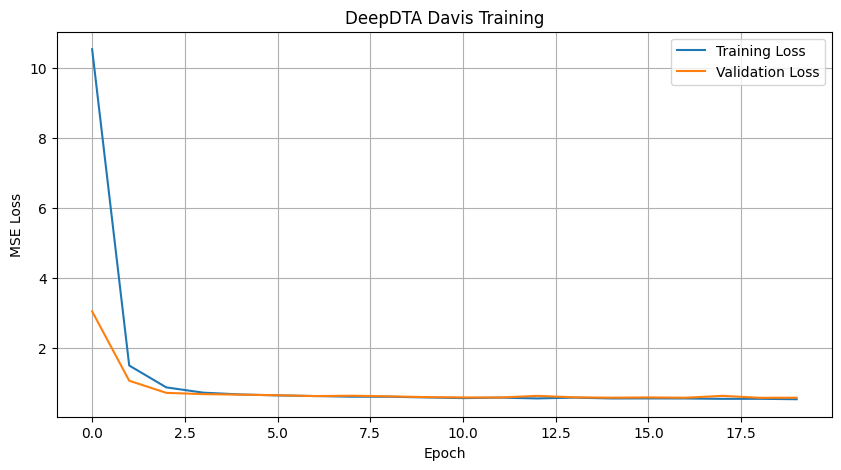

In [36]:
# ============================================================
# CELL 36: TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt


plt.figure(
    figsize=(10, 5)
)


plt.plot(
    history.history["loss"],
    label="Training Loss"
)


plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title(
    "DeepDTA Davis Training"
)

plt.legend()

plt.grid()

plt.show()

In [37]:
# ============================================================
# CELL 37: PREDICT
# ============================================================

y_pred = model.predict(
    [
        X_dr_test,
        X_pr_test
    ],
    batch_size=256
).flatten()


print(
    "Prediction completed."
)


print(
    "\nActual pKd:"
)

print(
    y_test[:10]
)


print(
    "\nPredicted pKd:"
)

print(
    y_pred[:10]
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step
Prediction completed.

Actual pKd:
[5.        5.        5.        8.823909  5.        5.        5.5686364
 5.        5.        5.       ]

Predicted pKd:
[5.4254575 6.053134  5.045461  6.4790797 5.622515  5.469172  5.884828
 6.087685  6.119756  5.567825 ]


In [38]:
# ============================================================
# CELL 38: MSE + RMSE
# ============================================================

mse = mean_squared_error(
    y_test,
    y_pred
)


rmse = np.sqrt(
    mse
)


print(
    "Test MSE:",
    mse
)


print(
    "Test RMSE:",
    rmse
)

Test MSE: 0.5777885913848877
Test RMSE: 0.7601240631534353


In [39]:
# ============================================================
# CELL 39: CONCORDANCE INDEX
# ============================================================

def concordance_index(
    y_true,
    y_pred
):

    n = 0

    h_sum = 0.0


    for i in range(
        len(y_true)
    ):

        for j in range(
            i + 1,
            len(y_true)
        ):

            if (
                y_true[i]
                ==
                y_true[j]
            ):
                continue


            n += 1


            true_difference = (
                y_true[i]
                -
                y_true[j]
            )


            pred_difference = (
                y_pred[i]
                -
                y_pred[j]
            )


            if (
                true_difference
                *
                pred_difference
            ) > 0:

                h_sum += 1


            elif (
                pred_difference
                == 0
            ):

                h_sum += 0.5


    if n == 0:

        return 0


    return h_sum / n


ci = concordance_index(
    y_test,
    y_pred
)


print(
    "Concordance Index:",
    ci
)

Concordance Index: 0.7815826427807744


In [40]:
# ============================================================
# CELL 40: PEARSON CORRELATION
# ============================================================

pearson_corr, p_value = pearsonr(
    y_test,
    y_pred
)


print(
    "Pearson Correlation:",
    pearson_corr
)


print(
    "P-value:",
    p_value
)

Pearson Correlation: 0.5328458
P-value: 0.0


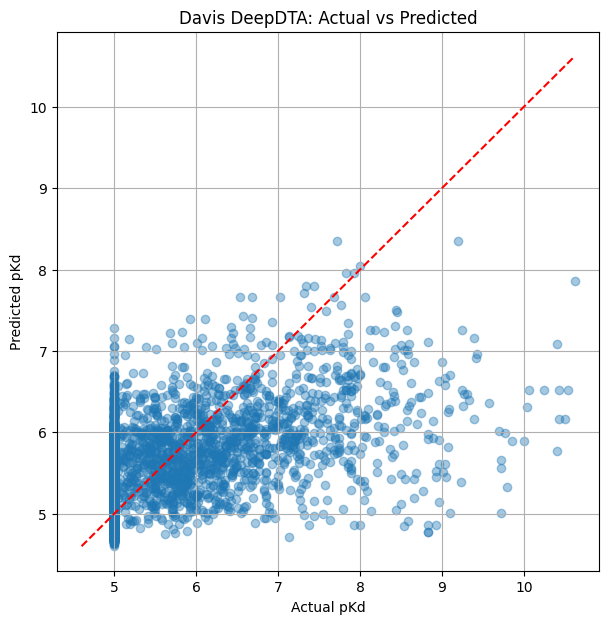

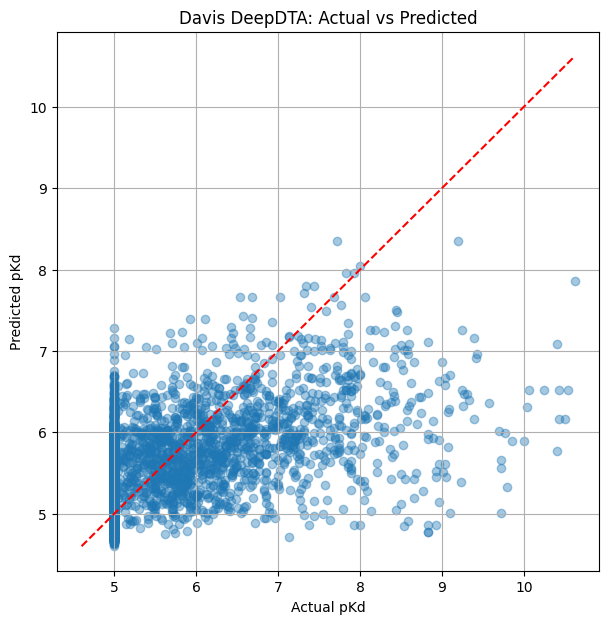

In [41]:
# ============================================================
# CELL 41: ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(7, 7)
)


plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)


min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)


plt.plot(
    [
        min_value,
        max_value
    ],
    [
        min_value,
        max_value
    ],
    "r--"
)


plt.xlabel(
    "Actual pKd"
)

plt.ylabel(
    "Predicted pKd"
)

plt.title(
    "Davis DeepDTA: Actual vs Predicted"
)

plt.grid()

plt.show()# ============================================================
# CELL 41: ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(7, 7)
)


plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)


min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)


plt.plot(
    [
        min_value,
        max_value
    ],
    [
        min_value,
        max_value
    ],
    "r--"
)


plt.xlabel(
    "Actual pKd"
)

plt.ylabel(
    "Predicted pKd"
)

plt.title(
    "Davis DeepDTA: Actual vs Predicted"
)

plt.grid()

plt.show()

In [42]:
# ============================================================
# CELL 42: SAVE MODEL
# ============================================================

model.save(
    "DeepDTA_Davis_model.h5"
)


print(
    "✓ Model saved successfully."
)

✓ Model saved successfully.


In [43]:
# ============================================================
# CELL 43: SAVE VOCABULARIES
# ============================================================

with open(
    "davis_smiles_vocab.json",
    "w"
) as f:

    json.dump(
        smiles_vocab,
        f
    )


with open(
    "davis_protein_vocab.json",
    "w"
) as f:

    json.dump(
        protein_vocab,
        f
    )


print(
    "✓ SMILES vocabulary saved."
)

print(
    "✓ Protein vocabulary saved."
)

✓ SMILES vocabulary saved.
✓ Protein vocabulary saved.


In [44]:
# ============================================================
# CELL 44: SAVE MODEL CONFIGURATION
# ============================================================

config = {

    "dataset": "Davis",

    "smiles_representation":
        "canonical",

    "max_smiles_length":
        MAX_SMILES_LEN,

    "max_protein_length":
        MAX_PROTEIN_LEN,

    "embedding_dimension":
        EMBED_DIM,

    "smiles_vocab_size":
        SMILES_VOCAB_SIZE,

    "protein_vocab_size":
        PROTEIN_VOCAB_SIZE,

    "target":
        "pKd",

    "affinity_original":
        "Kd_nM",

    "pKd_formula":
        "-log10(Kd/1e9)",

    "batch_size":
        256,

    "epochs":
        20
}


with open(
    "davis_model_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


print(
    json.dumps(
        config,
        indent=4
    )
)

{
    "dataset": "Davis",
    "smiles_representation": "canonical",
    "max_smiles_length": 100,
    "max_protein_length": 1000,
    "embedding_dimension": 128,
    "smiles_vocab_size": 24,
    "protein_vocab_size": 22,
    "target": "pKd",
    "affinity_original": "Kd_nM",
    "pKd_formula": "-log10(Kd/1e9)",
    "batch_size": 256,
    "epochs": 20
}


In [45]:
from google.colab import files

files.download("DeepDTA_Davis_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>